# Contrastive Vision Agent Pretraining

This notebook implements the paper's Vision Agent pretraining stage for Vision-Driven MARL on JAX-LOB. It learns a 2D LOB representation from normalized Top-10 order book snapshots with InfoNCE: two augmented views of the same snapshot are positives and other batch snapshots are negatives.

Input tensors are expected to have shape `[N, 10, 3, 2]`, where each snapshot stores `[Gap, LogVol, CumVol]` across ask/bid sides. The learned CNN encoder parameters and embeddings are saved for later gated fusion or RL fine-tuning.

## 1. Setup

The local `l` conda environment has CUDA-backed JAX, but CUDA device initialization can segfault on this machine. Force CPU before importing JAX for a reliable notebook run.

In [22]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

from pathlib import Path
import json
import time

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from flax import linen as nn
from flax import serialization
from flax.training import train_state
import optax

REGENERATE_DATA = False
DATA_PATH = "vision_obs_all.npy"
OUTPUT_DIR = Path("outputs")

EPOCHS = int(os.getenv("VIT_MARL_CL_EPOCHS", "100"))
BATCH_SIZE = 64
TEMPERATURE = 0.1
EMBED_DIM = 64
SEED = 0
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

JITTER_STD = 0.03
LEVEL_KEEP_PROB = 0.9
FEATURE_KEEP_PROB = 0.9

OUTPUT_DIR.mkdir(exist_ok=True)

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())
print("Epochs:", EPOCHS)

JAX version: 0.10.0
JAX devices: [CpuDevice(id=0)]
Epochs: 100


## 2. Data Loading

By default this notebook loads the cached `vision_obs_all.npy`. Set `REGENERATE_DATA = True` to rebuild the tensor from the LOBSTER CSV files using `ExecutionAgent._get_obs_vision(..., normalize=True)`.

In [23]:
def regenerate_vision_observations(
    max_windows=None,
    process_window_msgs=False,
    max_msgs_per_window=100,
):
    """Rebuild normalized `[N, 10, 3, 2]` LOB vision tensors from CSV data."""
    from gymnax_exchange.jaxob import JaxOrderBookArrays as job
    from gymnax_exchange.jaxob.jaxob_config import (
        Execution_EnvironmentConfig,
        JAXLOB_Configuration,
        World_EnvironmentConfig,
    )
    from gymnax_exchange.jaxen.StatesandParams import WorldState
    from gymnax_exchange.jaxen.vision_env import ExecutionAgent
    from lobster_loader import LoadLOBSTER_resample

    repo_root = Path.cwd()
    loader = LoadLOBSTER_resample(
        datapath=str(repo_root),
        atpath=str(repo_root),
        stock="AMZN",
        time_period="2012-06-21",
        n_Levels=10,
        n_data_msg_per_step=100,
        day_start=34200,
        day_end=57600,
        type_="fixed_time",
        window_length=1800,
        window_resolution=60,
    )
    msgs, starts, ends, snapshots, _ = loader.run_loading()

    lob_cfg = JAXLOB_Configuration()
    world_config = World_EnvironmentConfig()
    exec_config = Execution_EnvironmentConfig(
        action_space="simplest_case",
        observation_space="execution_policy",
    )
    agent = ExecutionAgent(cfg=exec_config, world_config=world_config)
    scan_book = jax.jit(job.scan_through_entire_array, static_argnums=(0,))

    n_windows_total = min(len(starts), len(ends), len(snapshots))
    n_windows = n_windows_total if max_windows is None else min(n_windows_total, max_windows)
    rng = jax.random.PRNGKey(SEED)
    out = []

    for i in range(n_windows):
        rng, subkey = jax.random.split(rng)
        now = jnp.array([34200 + i * 60, 0])
        init_orders = job.init_msgs_from_l2(lob_cfg, snapshots[i], time=now)
        asks = job.init_orderside(lob_cfg.nOrders)
        bids = job.init_orderside(lob_cfg.nOrders)
        trades = (jnp.ones((lob_cfg.nTrades, 8)) * -1).astype(jnp.int32)
        asks, bids, trades = scan_book(lob_cfg, subkey, init_orders, (asks, bids, trades))

        if process_window_msgs:
            start_i = int(starts[i])
            end_i = int(ends[i])
            actual_len = min(max(0, end_i - start_i), max_msgs_per_window)
            if actual_len > 0:
                rng, subkey = jax.random.split(rng)
                raw_slice = msgs[start_i:start_i + actual_len]
                pad_len = max_msgs_per_window - actual_len
                if pad_len > 0:
                    padding = jnp.zeros((pad_len, raw_slice.shape[1]), dtype=raw_slice.dtype)
                    window_msgs = jnp.concatenate([raw_slice, padding], axis=0)
                else:
                    window_msgs = raw_slice
                asks, bids, trades = scan_book(lob_cfg, subkey, window_msgs, (asks, bids, trades))

        best_bid, best_ask = job.get_best_bid_and_ask_inclQuants(lob_cfg, asks, bids)
        mid_price = (best_ask[0] + best_bid[0]) / 2
        world_state = WorldState(
            ask_raw_orders=asks,
            bid_raw_orders=bids,
            trades=trades,
            init_time=now,
            window_index=i,
            max_steps_in_episode=100,
            start_index=int(starts[i]),
            step_counter=0,
            best_bids=jnp.array([best_bid]),
            best_asks=jnp.array([best_ask]),
            time=now,
            order_id_counter=0,
            mid_price=mid_price,
            delta_time=0.0,
        )
        out.append(np.asarray(agent._get_obs_vision(world_state, normalize=True)))

    return np.stack(out, axis=0).astype(np.float32)


data_path = Path(DATA_PATH)
if REGENERATE_DATA:
    vision_obs_all = regenerate_vision_observations()
    np.save(data_path, vision_obs_all)
else:
    vision_obs_all = np.load(data_path)

vision_obs_all = vision_obs_all.astype(np.float32)
if vision_obs_all.ndim != 4 or vision_obs_all.shape[1:] != (10, 3, 2):
    raise ValueError(f"Expected `[N, 10, 3, 2]`, got {vision_obs_all.shape}")
if not np.isfinite(vision_obs_all).all():
    raise ValueError("Vision tensor contains non-finite values")

print("vision_obs_all shape:", vision_obs_all.shape)
print("dtype:", vision_obs_all.dtype)
print("min/max:", float(vision_obs_all.min()), float(vision_obs_all.max()))

vision_obs_all shape: (130, 10, 3, 2)
dtype: float32
min/max: 0.5 623.5


## 3. Standardization and Visualization

The paper's heuristic LOB normalization makes features price-level invariant. The training loop additionally standardizes each channel over the dataset to stabilize InfoNCE optimization.

standardized mean: [[-0. -0.]
 [-0. -0.]
 [-0. -0.]]
standardized std: [[1. 1.]
 [1. 1.]
 [1. 1.]]


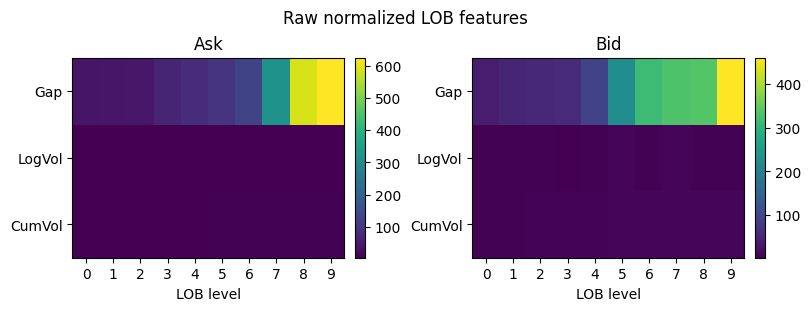

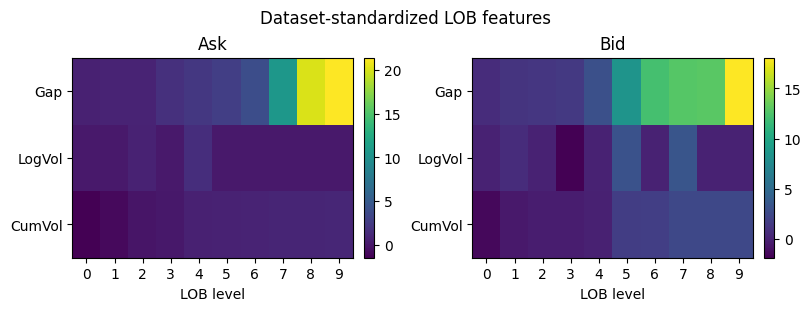

In [24]:
feature_mean = vision_obs_all.mean(axis=(0, 1), keepdims=True)
feature_std = vision_obs_all.std(axis=(0, 1), keepdims=True)
feature_std = np.where(feature_std < 1e-6, 1.0, feature_std)
x_data = ((vision_obs_all - feature_mean) / feature_std).astype(np.float32)

print("standardized mean:", np.round(x_data.mean(axis=(0, 1)), 4))
print("standardized std:", np.round(x_data.std(axis=(0, 1)), 4))

def plot_lob_snapshot(snapshot, title):
    feature_names = ["Gap", "LogVol", "CumVol"]
    side_names = ["Ask", "Bid"]
    fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
    for side_idx, ax in enumerate(axes):
        image = snapshot[:, :, side_idx].T
        im = ax.imshow(image, aspect="auto", cmap="viridis")
        ax.set_title(side_names[side_idx])
        ax.set_xlabel("LOB level")
        ax.set_xticks(range(snapshot.shape[0]))
        ax.set_yticks(range(len(feature_names)))
        ax.set_yticklabels(feature_names)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    return fig

plot_lob_snapshot(vision_obs_all[0], "Raw normalized LOB features")
plot_lob_snapshot(x_data[0], "Dataset-standardized LOB features")
plt.show()

## 4. CNN Vision Agent and InfoNCE

The encoder keeps the 2D LOB structure instead of flattening the snapshot. The projection head is used for the contrastive loss; the encoder embedding is what gets saved for later fusion.

In [25]:
class VisionCNN(nn.Module):
    embed_dim: int = EMBED_DIM
    projection_dim: int = EMBED_DIM

    @nn.compact
    def __call__(self, x, train=False, return_projection=True):
        del train
        x = jnp.asarray(x, dtype=jnp.float32)
        x = nn.Conv(features=32, kernel_size=(3, 2), padding="SAME")(x)
        x = nn.relu(x)
        x = nn.LayerNorm()(x)
        x = nn.Conv(features=64, kernel_size=(3, 2), padding="SAME")(x)
        x = nn.relu(x)
        x = nn.LayerNorm()(x)
        x = x.mean(axis=(1, 2))
        embedding = nn.Dense(128)(x)
        embedding = nn.relu(embedding)
        embedding = nn.Dense(self.embed_dim, name="embedding")(embedding)
        if not return_projection:
            return embedding
        projection = nn.Dense(128)(embedding)
        projection = nn.relu(projection)
        projection = nn.Dense(self.projection_dim, name="projection")(projection)
        return projection


def l2_normalize(x, eps=1e-8):
    return x / jnp.maximum(jnp.linalg.norm(x, axis=-1, keepdims=True), eps)


def info_nce_loss(z_a, z_b, temperature=TEMPERATURE):
    z_a = l2_normalize(z_a)
    z_b = l2_normalize(z_b)
    logits = (z_a @ z_b.T) / temperature
    labels = jnp.arange(logits.shape[0])
    loss_a = optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()
    loss_b = optax.softmax_cross_entropy_with_integer_labels(logits.T, labels).mean()
    acc_a = (jnp.argmax(logits, axis=1) == labels).mean()
    acc_b = (jnp.argmax(logits.T, axis=1) == labels).mean()
    return 0.5 * (loss_a + loss_b), 0.5 * (acc_a + acc_b)


def augment_batch(rng, x):
    rng_jitter, rng_level, rng_feature = jax.random.split(rng, 3)
    jitter = JITTER_STD * jax.random.normal(rng_jitter, x.shape, dtype=x.dtype)
    level_mask = jax.random.bernoulli(
        rng_level,
        LEVEL_KEEP_PROB,
        shape=(x.shape[0], x.shape[1], 1, 1),
    )
    feature_mask = jax.random.bernoulli(
        rng_feature,
        FEATURE_KEEP_PROB,
        shape=(x.shape[0], 1, x.shape[2], 1),
    )
    return (x + jitter) * level_mask.astype(x.dtype) * feature_mask.astype(x.dtype)


model = VisionCNN(embed_dim=EMBED_DIM, projection_dim=EMBED_DIM)
rng = jax.random.PRNGKey(SEED)
rng, init_rng = jax.random.split(rng)
params = model.init(init_rng, jnp.asarray(x_data[: min(8, len(x_data))]))["params"]
optimizer = optax.adamw(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

test_projection = model.apply({"params": state.params}, jnp.asarray(x_data[:8]))
test_embedding = model.apply(
    {"params": state.params},
    jnp.asarray(x_data[:8]),
    return_projection=False,
)
print("projection shape:", test_projection.shape)
print("embedding shape:", test_embedding.shape)

projection shape: (8, 64)
embedding shape: (8, 64)


## 5. Training

In [26]:
@jax.jit
def train_step(state, batch, rng):
    rng_a, rng_b = jax.random.split(rng)
    view_a = augment_batch(rng_a, batch)
    view_b = augment_batch(rng_b, batch)

    def loss_fn(params):
        z_a = state.apply_fn({"params": params}, view_a, train=True)
        z_b = state.apply_fn({"params": params}, view_b, train=True)
        return info_nce_loss(z_a, z_b)

    (loss, acc), grads = jax.value_and_grad(loss_fn, has_aux=True)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss, acc


def iter_batches(array, rng_key, batch_size):
    n = array.shape[0]
    perm = np.asarray(jax.random.permutation(rng_key, n))
    for start in range(0, n, batch_size):
        idx = perm[start:start + batch_size]
        if len(idx) < 2:
            continue
        yield jnp.asarray(array[idx])


loss_history = []
acc_history = []
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    rng, epoch_rng = jax.random.split(rng)
    epoch_losses = []
    epoch_accs = []
    for batch in iter_batches(x_data, epoch_rng, BATCH_SIZE):
        rng, step_rng = jax.random.split(rng)
        state, loss, acc = train_step(state, batch, step_rng)
        epoch_losses.append(float(loss))
        epoch_accs.append(float(acc))

    mean_loss = float(np.mean(epoch_losses))
    mean_acc = float(np.mean(epoch_accs))
    loss_history.append(mean_loss)
    acc_history.append(mean_acc)
    if epoch == 1 or epoch == EPOCHS or epoch % max(1, EPOCHS // 10) == 0:
        print(f"epoch {epoch:03d}/{EPOCHS} loss={mean_loss:.4f} retrieval_acc={mean_acc:.3f}")

elapsed = time.time() - start_time
print(f"training time: {elapsed:.1f}s")
if not np.isfinite(loss_history[-1]):
    raise RuntimeError("Final InfoNCE loss is not finite")

epoch 001/100 loss=2.1660 retrieval_acc=0.669
epoch 010/100 loss=1.3093 retrieval_acc=0.682
epoch 020/100 loss=0.9892 retrieval_acc=0.758
epoch 030/100 loss=0.8723 retrieval_acc=0.784
epoch 040/100 loss=0.6924 retrieval_acc=0.826
epoch 050/100 loss=0.6730 retrieval_acc=0.826
epoch 060/100 loss=0.5846 retrieval_acc=0.865
epoch 070/100 loss=0.6558 retrieval_acc=0.833
epoch 080/100 loss=0.5574 retrieval_acc=0.872
epoch 090/100 loss=0.8850 retrieval_acc=0.786
epoch 100/100 loss=0.5728 retrieval_acc=0.872
training time: 7.7s


## 6. Embedding Diagnostics

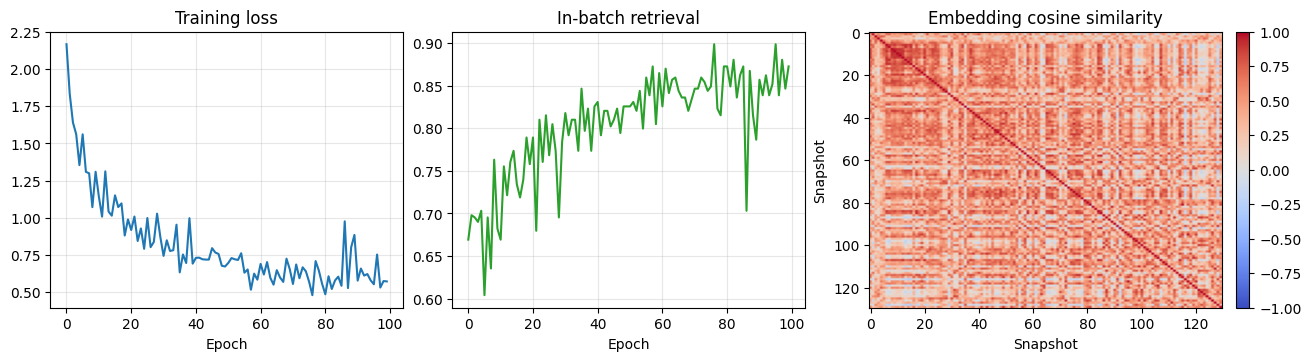

embeddings shape: (130, 64)
embedding norm mean/std: 1.0 5.750440479346253e-08


In [27]:
@jax.jit
def encode(params, batch):
    emb = model.apply({"params": params}, batch, return_projection=False)
    return l2_normalize(emb)


embeddings = np.asarray(encode(state.params, jnp.asarray(x_data)))
similarity = embeddings @ embeddings.T

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
axes[0].plot(loss_history, label="InfoNCE loss")
axes[0].set_xlabel("Epoch")
axes[0].set_title("Training loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(acc_history, label="Retrieval acc", color="tab:green")
axes[1].set_xlabel("Epoch")
axes[1].set_title("In-batch retrieval")
axes[1].grid(True, alpha=0.3)

im = axes[2].imshow(similarity, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
axes[2].set_title("Embedding cosine similarity")
axes[2].set_xlabel("Snapshot")
axes[2].set_ylabel("Snapshot")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.show()

print("embeddings shape:", embeddings.shape)
print("embedding norm mean/std:", float(np.linalg.norm(embeddings, axis=1).mean()), float(np.linalg.norm(embeddings, axis=1).std()))

## 7. Save Artifacts

These outputs are the bridge to the next stage of the paper: initializing the Vision Agent used by gated fusion or adding `R_vision = -L_NCE` as a regularizer during RL fine-tuning.

In [28]:
params_path = OUTPUT_DIR / "vision_agent_contrastive_cnn.msgpack"
config_path = OUTPUT_DIR / "vision_agent_contrastive_config.json"
embeddings_path = OUTPUT_DIR / "vision_embeddings.npy"
metrics_path = OUTPUT_DIR / "contrastive_training_metrics.npz"

with params_path.open("wb") as f:
    f.write(serialization.to_bytes(state.params))

config = {
    "data_path": DATA_PATH,
    "input_shape": list(vision_obs_all.shape[1:]),
    "n_snapshots": int(vision_obs_all.shape[0]),
    "epochs": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "temperature": float(TEMPERATURE),
    "embed_dim": int(EMBED_DIM),
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
    "jitter_std": float(JITTER_STD),
    "level_keep_prob": float(LEVEL_KEEP_PROB),
    "feature_keep_prob": float(FEATURE_KEEP_PROB),
    "feature_mean": feature_mean.squeeze(0).tolist(),
    "feature_std": feature_std.squeeze(0).tolist(),
    "jax_platforms": os.environ.get("JAX_PLATFORMS"),
    "paper_stage": "Vision Agent InfoNCE pretraining",
}
with config_path.open("w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

np.save(embeddings_path, embeddings.astype(np.float32))
np.savez(
    metrics_path,
    loss=np.asarray(loss_history, dtype=np.float32),
    retrieval_acc=np.asarray(acc_history, dtype=np.float32),
)

for path in [params_path, config_path, embeddings_path, metrics_path]:
    if not path.exists() or path.stat().st_size == 0:
        raise RuntimeError(f"Artifact was not written correctly: {path}")
    print(path, path.stat().st_size, "bytes")

outputs/vision_agent_contrastive_cnn.msgpack 184924 bytes
outputs/vision_agent_contrastive_config.json 890 bytes
outputs/vision_embeddings.npy 33408 bytes
outputs/contrastive_training_metrics.npz 1320 bytes
